# Phase 3: Diabetes Risk Classification Modeling

**Objective:** Develop a machine learning classification model to predict a patient's `diabetes_stage` for the BC Analytics Decision Support System. 

**Models Evaluated:**
1. Decision Tree (Baseline)
2. Random Forest 
3. XGBoost (Final Selection)

---

## 1. Environment Setup & Data Acquisition

This initial phase establishes the workspace and loads the primary dataset for analysis.

### **Libraries and Dependencies**
* **Data Manipulation**: `pandas` and `numpy` for efficient data handling.
* **Modeling & Selection**: `scikit-learn` for traditional tree-based models and training splits.
* **Gradient Boosting**: `XGBoost` for high-performance classification.
* **Evaluation**: Comprehensive metrics including `accuracy_score`, `f1_score`, and `confusion_matrix`.

### **Data Loading**
We import the cleaned `Diabetes_and_LifeStyle_Dataset_.csv` to confirm the structure and feature alignment before moving into the data preparation phase.

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

# Load the dataset
df = pd.read_csv('../data/Diabetes_and_LifeStyle_Dataset_.csv')

# Display the first few rows to confirm it loaded
df.head()

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


---

## 2. Feature Engineering & Data Splitting
To prepare the data for the CRISP-DM modeling phase, we perform the following:
* **Leakage Prevention:** Removing `diabetes_risk_score` and `diagnosed_diabetes`.
* **Target Encoding:** Mapping the categorical `diabetes_stage` to numerical values.
* **One-Hot Encoding:** Converting lifestyle categories into a machine-readable format.
* **Stratified Split:** Using an 80/20 split to ensure even distribution of diabetes stages.

In [39]:
from sklearn.preprocessing import LabelEncoder

# 1. Drop columns that cause data leakage
df_clean = df.drop(columns=['diabetes_risk_score', 'diagnosed_diabetes'])

# 2. Separate Features (X) and Target (y)
X_raw = df_clean.drop(columns=['diabetes_stage'])
y_raw = df_clean['diabetes_stage']

# 3. Encode the Target (y) into numbers 
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

# Print the mapping so we know which number corresponds to which stage
target_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Target classes mapped to numbers:", target_mapping)

# 4. One-Hot Encode the categorical features in X
X = pd.get_dummies(X_raw, drop_first=True)

# 5. Train-Test Split (80% training, 20% testing)
# Using stratify=y ensures a fair distribution of diabetes stages in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Target classes mapped to numbers: {'Gestational': np.int64(0), 'No Diabetes': np.int64(1), 'Pre-Diabetes': np.int64(2), 'Type 1': np.int64(3), 'Type 2': np.int64(4)}
Training data shape: (77837, 40)
Testing data shape: (19460, 40)


---

## 3. Baseline Model: Decision Tree
Establishing a baseline to understand initial predictive power. 
* **Constraint:** `max_depth=10` is applied to avoid overfitting.
* **Goal:** Use this as a benchmark for more complex ensemble methods.

In [40]:
# 1. Initialize the Decision Tree Classifier
# We set max_depth=10 to prevent the tree from growing too complex and memorizing the training data (overfitting)
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)

# 2. Train (fit) the model on the training data
dt_model.fit(X_train, y_train)

# 3. Make predictions on the unseen testing data
y_pred_dt = dt_model.predict(X_test)

# 4. Evaluate the model
print("--- Decision Tree Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}\n")

# The classification report shows precision, recall, and f1-score for each specific diabetes stage
print("Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_))

--- Decision Tree Performance ---
Accuracy: 0.9126

Classification Report:
              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        53
 No Diabetes       0.85      0.98      0.91      1548
Pre-Diabetes       0.82      0.99      0.90      6203
      Type 1       0.00      0.00      0.00        23
      Type 2       0.99      0.87      0.92     11633

    accuracy                           0.91     19460
   macro avg       0.53      0.57      0.55     19460
weighted avg       0.92      0.91      0.91     19460



---

## 4. Random Forest (Ensemble Learning)
Improving performance by building multiple decision trees.
* **Class Weights:** We use `class_weight='balanced'` to attempt to address the severe lack of Type 1 and Gestational data.

In [41]:
# 1. Initialize the Random Forest model 
# We use n_estimators=100 (100 trees) and balanced weights to support minority classes
rf_model = RandomForestClassifier(
    random_state=42, 
    class_weight='balanced', 
    n_estimators=100
)

# 2. Train the model on the training data
rf_model.fit(X_train, y_train)

# 3. Make predictions on the testing data
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluate model performance
# Added zero_division=0 to silence warnings regarding classes with no predicted samples
print("--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")

report_rf = classification_report(
    y_test, 
    y_pred_rf, 
    target_names=label_encoder.classes_, 
    zero_division=0
)

print(report_rf)

--- Random Forest Performance ---
Accuracy: 0.9152

              precision    recall  f1-score   support

 Gestational       0.00      0.00      0.00        53
 No Diabetes       0.85      0.99      0.91      1548
Pre-Diabetes       0.82      1.00      0.90      6203
      Type 1       0.00      0.00      0.00        23
      Type 2       0.99      0.87      0.93     11633

    accuracy                           0.92     19460
   macro avg       0.53      0.57      0.55     19460
weighted avg       0.92      0.92      0.91     19460



---

## 5. Final Model Implementation: XGBoost

This section implements the **XGBoost Classifier**. We use instance weighting to address the significant class imbalance between common and rare diabetes types.

* **Optimization**: Manual `sample_weights` are applied to the training set.
* **Generalization**: Parameters like `max_depth` and `learning_rate` are tuned to prevent overfitting on the majority classes.

In [42]:
from sklearn.utils.class_weight import compute_sample_weight

# 1. Calculate heavy penalty weights for the minority classes
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Initialize XGBoost
# We removed 'use_label_encoder' to clear the deprecation warning
xgb_model = XGBClassifier(
    random_state=42, 
    eval_metric='mlogloss',
    max_depth=6,          
    learning_rate=0.1,    
    n_estimators=200      
)

# 3. Train the model using the calculated sample weights
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# 4. Predict
y_pred_xgb = xgb_model.predict(X_test)

# 5. Evaluate
# zero_division=0 is added to prevent warnings if minority classes have 0 predictions
print("--- XGBoost Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}\n")
print(classification_report(
    y_test, 
    y_pred_xgb, 
    target_names=label_encoder.classes_, 
    zero_division=0
))

--- XGBoost Performance ---
Accuracy: 0.9107

              precision    recall  f1-score   support

 Gestational       0.01      0.02      0.01        53
 No Diabetes       0.84      1.00      0.91      1548
Pre-Diabetes       0.82      0.99      0.90      6203
      Type 1       0.00      0.00      0.00        23
      Type 2       1.00      0.86      0.92     11633

    accuracy                           0.91     19460
   macro avg       0.53      0.57      0.55     19460
weighted avg       0.93      0.91      0.91     19460



---

## 6. Visual Evaluation & Class Distribution

To communicate our findings to BC Analytics, we generate visual representations of the data and model performance. These visuals highlight the underlying challenges found during the modeling phase.

### **Key Visualizations:**
1.  **Class Distribution**: A bar chart demonstrating the extreme disparity between "Type 2" patients and minority classes like "Type 1".
2.  **Confusion Matrix**: A heatmap visualization showing exactly where the XGBoost model misclassified patients.
3.  **Performance Comparison**: A high-level overview of accuracy across the three evaluated algorithms.

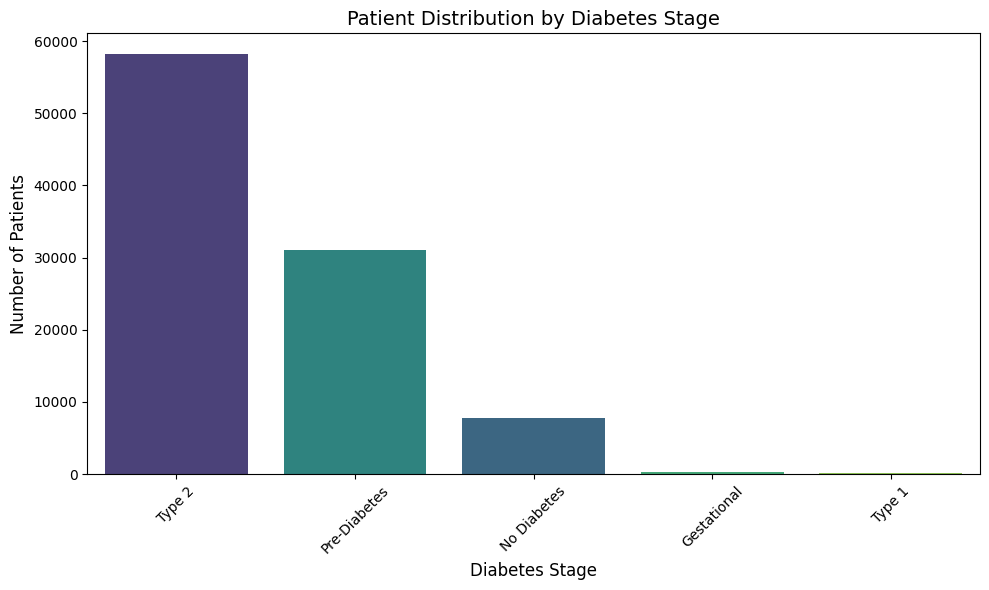

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Class Imbalance Chart ---
plt.figure(figsize=(10, 6))

# Fixed: Assigned x to hue and set legend=False to clear the FutureWarning
sns.countplot(
    data=df_clean, 
    x='diabetes_stage', 
    hue='diabetes_stage',
    order=df_clean['diabetes_stage'].value_counts().index, 
    palette='viridis',
    legend=False
)

plt.title('Patient Distribution by Diabetes Stage', fontsize=14)
plt.ylabel('Number of Patients', fontsize=12)
plt.xlabel('Diabetes Stage', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

# Save the figure for the Technical Report
plt.savefig('../artifacts/class_imbalance_chart.png')
plt.show()

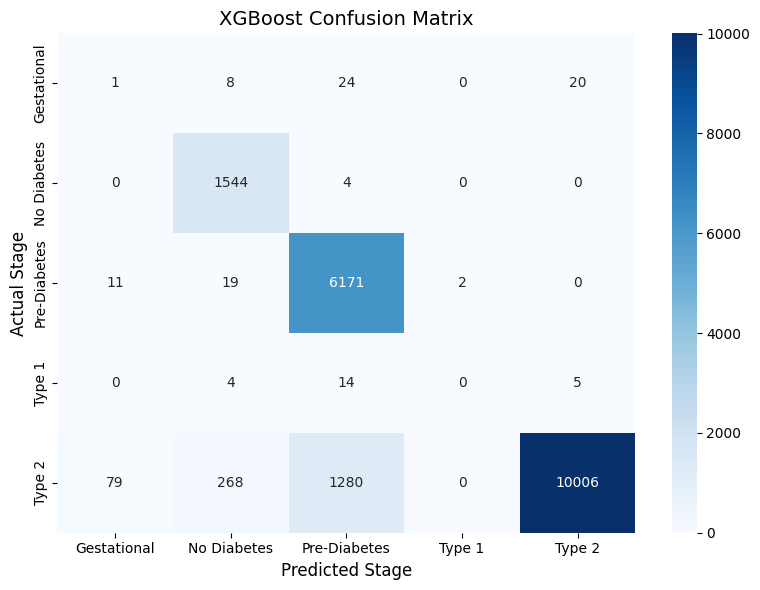

In [44]:
# 1. Generate the confusion matrix for XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)

# 2. Plot it using Seaborn's heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)

plt.title('XGBoost Confusion Matrix', fontsize=14)
plt.ylabel('Actual Stage', fontsize=12)
plt.xlabel('Predicted Stage', fontsize=12)
plt.tight_layout()

plt.savefig('../artifacts/xgboost_confusion_matrix.png')
plt.show()


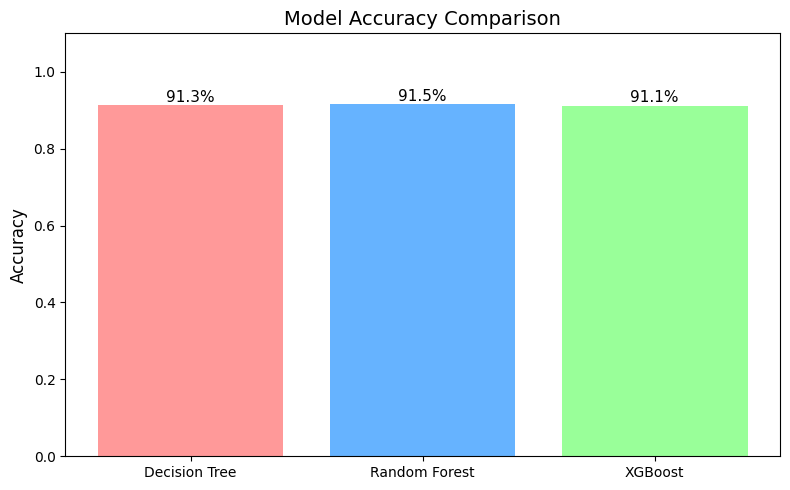

In [45]:
# 1. Store the accuracy scores we calculated earlier
models = ['Decision Tree', 'Random Forest', 'XGBoost']
accuracies = [
    accuracy_score(y_test, y_pred_dt), 
    accuracy_score(y_test, y_pred_rf), 
    accuracy_score(y_test, y_pred_xgb)
]

# 2. Plot the comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['#ff9999','#66b3ff','#99ff99'])

# Add the exact percentages on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval*100:.1f}%', ha='center', fontsize=11)

plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1.1) # Give room for the text at the top
plt.tight_layout()

plt.savefig('../artifacts/model_comparison.png')
plt.show()


---

## 7. Artifact Export
Finalizing Phase 3 by saving binary files to the `/artifacts` directory:
* `model_1.pkl`: The trained XGBoost classifier.
* `label_encoder.pkl`: Used for decoding predictions in the Web App.

In [46]:
import joblib
import os

# 1. Create the artifacts folder if it doesn't exist yet
os.makedirs('../artifacts', exist_ok=True)

# 2. Save the trained XGBoost model as model_1.pkl
joblib.dump(xgb_model, '../artifacts/model_1.pkl')

# 3. Save the Label Encoder so the web app can decode the predictions later
joblib.dump(label_encoder, '../artifacts/label_encoder.pkl')

print("Success! Model and encoder saved to the artifacts folder.")

Success! Model and encoder saved to the artifacts folder.
